In [9]:
import numpy as np
import torch
from torch.utils.data import Dataset
import minari
from matplotlib.patches import Rectangle
import mujoco
import random
from matplotlib import pyplot as plt


class MinariTrajectoryDatasetIndependentSkips(Dataset):
    """
    Dataset for loading state (position) and skip-value trajectory sequences from Minari
    with INDEPENDENT skip sampling for temporal compositionality.


    Key features:
    - On-the-fly generation: Every access generates fresh skip patterns
    - Log-normal(μ=1, σ=1) distribution: Mode at 1, heavy-tailed, allows fractional skips
    - No clipping: Uses rejection sampling to ensure windows fit in trajectories
    - Parallel skip computation: Efficiently samples all skips at once
    - Full trajectory coverage: Can start anywhere in trajectory

    Returned per-window sample shape: (H, 3)
      [:, 0:2] -> normalized positions (x, y)
      [:, 2]   -> normalized skip value (action)
    """

    def __init__(
        self,
        dataset_name="D4RL/pointmaze/umaze-v2",
        horizon=32,
        normalize=True,
        samples_per_trajectory=100,
        max_rejection_attempts=1000,
    ):
        self.horizon = horizon
        self.samples_per_trajectory = samples_per_trajectory
        self.max_rejection_attempts = max_rejection_attempts
        self.normalize_flag = normalize

        # Log-normal(1, 1) parameters - fixed, no hyperparameters to tune
        self.lognormal_mu = 1.0
        self.lognormal_sigma = 1.0

        # Load dataset
        self.dataset = minari.load_dataset(dataset_name, download=True)

        # Store trajectories (just positions)
        self.trajectories = []
        all_positions = []

        # Process episodes
        for episode in self.dataset:
            obs = episode.observations
            if isinstance(obs, dict):
                obs = obs["observation"]

            states = obs  # full env states, e.g. (x, y, vx, vy)
            positions = states[:, :2].astype(np.float32)

            # Only keep trajectories long enough for at least one skip
            if len(positions) >= 2:
                self.trajectories.append(positions)
                all_positions.append(positions)

        if len(self.trajectories) == 0:
            raise ValueError("No valid trajectories found in dataset")

        # Compute normalization statistics
        all_positions = np.concatenate(all_positions, axis=0)

        self.state_dim = 2  # (x, y)
        self.action_dim = 1  # skip value
        self.traj_dim = self.state_dim + self.action_dim  # 3

        if normalize:
            self.pos_mean = all_positions.mean(axis=0).astype(np.float32)
            self.pos_std = all_positions.std(axis=0).astype(np.float32) + 1e-8
        else:
            self.pos_mean = np.zeros(self.state_dim, dtype=np.float32)
            self.pos_std = np.ones(self.state_dim, dtype=np.float32)

        # Skip normalization statistics (computed from lognormal parameters)
        # For LogNormal(μ, σ): mean = exp(μ + σ²/2), std = sqrt((exp(σ²) - 1) * exp(2μ + σ²))
        self.skip_mean = np.exp(self.lognormal_mu + self.lognormal_sigma**2 / 2)  # ≈ 4.48
        variance = (np.exp(self.lognormal_sigma**2) - 1) * np.exp(2 * self.lognormal_mu + self.lognormal_sigma**2)
        self.skip_std = np.sqrt(variance)  # ≈ 11.1

        # Combined mean/std over full trajectory vector [x, y, skip]
        self.mean = np.zeros(self.traj_dim, dtype=np.float32)
        self.std = np.ones(self.traj_dim, dtype=np.float32)

        self.mean[:self.state_dim] = self.pos_mean
        self.std[:self.state_dim] = self.pos_std
        self.mean[self.state_dim] = self.skip_mean
        self.std[self.state_dim] = self.skip_std

        # Build index: each trajectory gets multiple virtual samples
        self.indices = []
        for traj_idx in range(len(self.trajectories)):
            for _ in range(self.samples_per_trajectory):
                self.indices.append(traj_idx)

    def _sample_skips_parallel(self, n_skips):
        """
        Sample n_skips values from LogNormal(μ=1, σ=1) in parallel.

        Returns:
            np.array of shape (n_skips,) with skip values
        """
        return np.random.lognormal(
            mean=self.lognormal_mu,
            sigma=self.lognormal_sigma,
            size=n_skips
        ).astype(np.float32)

    def _interpolate_position(self, positions, tau):
        """
        Interpolate position at continuous time tau.

        Args:
            positions: (T, 2) array of positions
            tau: float in [0, T-1]

        Returns:
            (2,) interpolated position
        """
        T = len(positions)
        tau_clamped = np.clip(tau, 0, T - 1)
        idx = int(np.floor(tau_clamped))

        if idx >= T - 1:
            return positions[-1].copy()

        # Linear interpolation
        delta_t = tau_clamped - idx
        return positions[idx] + (positions[idx + 1] - positions[idx]) * delta_t

    def _generate_window_with_rejection(self, positions):
        """
        Generate a single window with random skip values using rejection sampling.

        This ensures the entire window fits within the trajectory without clipping.
        Uses parallel skip computation with ReLU-based cumulative sum check.

        Args:
            positions: (T, 2) array of positions for this trajectory

        Returns:
            window_positions: (horizon, 2) array
            window_skips: (horizon,) array
        """
        T = len(positions)

        for attempt in range(self.max_rejection_attempts):
            # Sample starting position uniformly from entire trajectory
            start_tau = np.random.uniform(0, T - 1)

            # Sample all skips in parallel
            skips = self._sample_skips_parallel(self.horizon)

            # Compute cumulative positions: tau_0, tau_1, ..., tau_H-1
            # tau_i = start_tau + sum(skips[0:i])
            cumulative_skips = np.cumsum(skips)
            taus = start_tau + np.concatenate([[0], cumulative_skips[:-1]])

            # Check if all taus are within bounds [0, T-1]
            # Using ReLU-like approach: max(0, tau - (T-1)) gives violation amount
            max_tau = taus[-1] + skips[-1]  # Last position after last skip

            if max_tau <= T - 1:
                # Success! All positions fit within trajectory
                window_positions = np.array([
                    self._interpolate_position(positions, tau)
                    for tau in taus
                ], dtype=np.float32)

                return window_positions, skips

        # If rejection sampling fails after max attempts, fall back to safe sampling
        # This should be extremely rare with lognormal(1,1)
        # Sample from first portion of trajectory to guarantee fit
        safe_start = np.random.uniform(0, max(0.1, T * 0.3))
        skips = self._sample_skips_parallel(self.horizon)

        # Scale skips down to fit
        cumulative_skips = np.cumsum(skips)
        max_extent = cumulative_skips[-1]
        available_space = T - 1 - safe_start

        if max_extent > available_space:
            skips = skips * (available_space / max_extent * 0.95)  # 95% to be safe

        cumulative_skips = np.cumsum(skips)
        taus = safe_start + np.concatenate([[0], cumulative_skips[:-1]])

        window_positions = np.array([
            self._interpolate_position(positions, tau)
            for tau in taus
        ], dtype=np.float32)

        return window_positions, skips

    def normalize_position(self, x):
        """Normalize positions (x,y)."""
        return (x - self.pos_mean) / self.pos_std

    def denormalize_position(self, x):
        """Denormalize positions (x,y)."""
        return x * self.pos_std + self.pos_mean

    def normalize_skip(self, skip):
        """Normalize skip values."""
        return (skip - self.skip_mean) / self.skip_std

    def denormalize_skip(self, skip):
        """Denormalize skip values."""
        return skip * self.skip_std + self.skip_mean

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        """
        Generate a trajectory window with independent skip values ON-THE-FLY.

        This is called fresh every time, so every epoch sees different skip patterns!

        Returns:
            torch.FloatTensor of shape (horizon, 3):
                [:, 0:2] - normalized (x, y) positions
                [:, 2] - normalized skip value
        """
        traj_idx = self.indices[idx]
        positions = self.trajectories[traj_idx]

        # Generate fresh window with rejection sampling (no clipping!)
        window_positions, window_skips = self._generate_window_with_rejection(positions)

        # Normalize
        positions_norm = self.normalize_position(window_positions)
        skips_norm = self.normalize_skip(window_skips)

        # Build trajectory tensor [H, 3]
        trajectory = np.zeros((self.horizon, self.traj_dim), dtype=np.float32)
        trajectory[:, :self.state_dim] = positions_norm
        trajectory[:, self.state_dim] = skips_norm

        return torch.FloatTensor(trajectory)

In [3]:
dataset = MinariTrajectoryDatasetIndependentSkips(
    dataset_name="D4RL/pointmaze/umaze-v2",
    horizon=32
)

In [14]:
from matplotlib.collections import LineCollection

def visualize_trajectory_with_skips(dataset, idx=0, figsize=(8, 8)):
    """
    Visualize a sampled window with skip values shown via colormap.

    Args:
        dataset: MinariTrajectoryDatasetIndependentSkips instance
        idx: Index to sample from
        figsize: Figure size
    """
    # Get a sample
    sample = dataset[idx]
    env = dataset.dataset.recover_environment()

    def unwrap_env(env):
        while hasattr(env, "env"):
            env = env.env
        return env

    env = unwrap_env(env)

    mj_model = env.model
    mj_data = env.data
    # Denormalize to get actual values
    positions = dataset.denormalize_position(sample[:, :2].numpy())
    skips = dataset.denormalize_skip(sample[:, 2].numpy())

    # Get the full trajectory this sample came from
    traj_idx = dataset.indices[idx]
    full_trajectory = dataset.trajectories[traj_idx]

    fig, ax = plt.subplots(figsize=figsize)

    # Plot full trajectory in background (faint)
    ax.plot(full_trajectory[:, 0], full_trajectory[:, 1],
            'gray', alpha=0.2, linewidth=1, zorder=1, label='Full trajectory')

    # Create line segments between consecutive sampled points
    points = positions.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    # Create LineCollection with colors based on skip values
    norm = plt.Normalize(vmin=skips.min(), vmax=skips.max())
    lc = LineCollection(segments, cmap='viridis', norm=norm, linewidths=3, zorder=2)
    lc.set_array(skips[:-1])  # Color each segment by its skip value
    line = ax.add_collection(lc)

    # Add colorbar
    cbar = plt.colorbar(line, ax=ax, label='Skip size (timesteps)')

    # Plot sampled points with color indicating skip value
    scatter = ax.scatter(positions[:, 0], positions[:, 1],
                        c=skips, cmap='viridis', s=50,
                        linewidth=2, zorder=3,
                        norm=norm)

    # Mark start and end of the sampled window
    ax.scatter(positions[0, 0], positions[0, 1],
              c='lime', s=100, marker='s',
              edgecolors='black', linewidth=2, zorder=4, label='Window start')
    ax.scatter(positions[-1, 0], positions[-1, 1],
              c='red', s=100, marker='s',
              edgecolors='black', linewidth=2, zorder=4, label='Window end')

    # Add skip value annotations
    # for i, (pos, skip) in enumerate(zip(positions, skips)):
    #     ax.annotate(f'{skip:.1f}',
    #                xy=pos, xytext=(5, 5),
    #                textcoords='offset points',
    #                fontsize=9,
    #                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

    # Render MuJoCo walls
    for geom_id in range(mj_model.ngeom):

        # Get geom name
        name = mujoco.mj_id2name(mj_model, mujoco.mjtObj.mjOBJ_GEOM, geom_id)

        if name is None or not "block" in name:
            continue

        pos = mj_model.geom_pos[geom_id]     # center (x, y, z)
        size = mj_model.geom_size[geom_id]   # half-extents (hx, hy, hz)

        cx, cy = pos[:2]
        hx, hy = size[:2]

        rect = Rectangle(
            (cx - hx, cy - hy),
            2 * hx,
            2 * hy,
            color="black",
            alpha=0.35,
            zorder=0
        )
        ax.add_patch(rect)

    ax.set_xlabel('X', fontsize=12)
    ax.set_ylabel('Y', fontsize=12)
    ax.set_title(f'PointMaze Trajectory with Skip Values\n'
                f'Total temporal extent: {skips.sum():.1f} timesteps',
                fontsize=14)
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

    plt.tight_layout()
    return fig, ax

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'PointMaze Trajectory with Skip Values\nTotal temporal extent: 72.8 timesteps'}, xlabel='X', ylabel='Y'>)

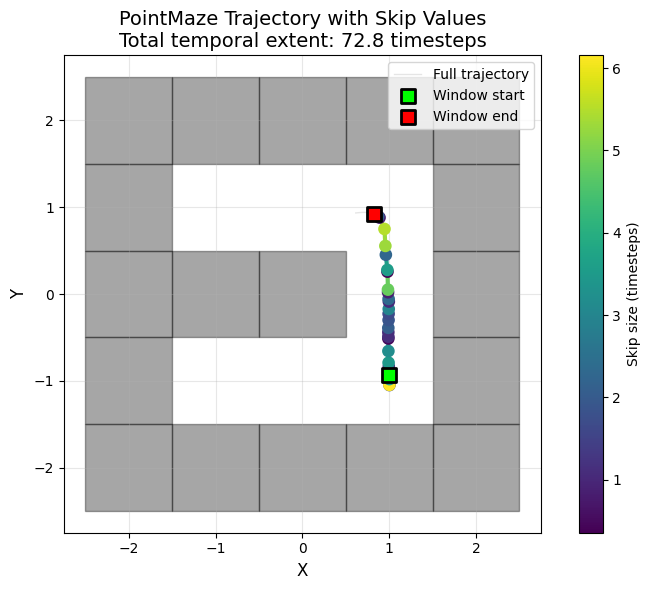

In [24]:
visualize_trajectory_with_skips(dataset, random.randint(0, len(dataset)-1), figsize=(8, 6))